In [1]:
from pathlib import Path
import sys


NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))


print("Notebook directory:", NOTEBOOK_DIR)
print("Project root:", PROJECT_ROOT)
print("Source directory:", SRC_DIR)

Notebook directory: C:\Users\znurs\Documents\DOKUMANLAR\zeynepnur\1-masters thesis\valorization_defect_chain\notebooks
Project root: C:\Users\znurs\Documents\DOKUMANLAR\zeynepnur\1-masters thesis\valorization_defect_chain
Source directory: C:\Users\znurs\Documents\DOKUMANLAR\zeynepnur\1-masters thesis\valorization_defect_chain\src


In [6]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:


from ssh_core import (
    spectral_correlation_matrix,
    extract_two_site_block,
)

from zero_mode import (
    compare_trial_and_numerical_mode,
)

from entanglement import (
    rho_from_two_site_correlation,
    concurrence_from_two_site_correlation,
)

from defect_analysis import (
    two_site_defect_decomposition,
    compare_pair_concurrences,
)

from plotting_defect import (
    plot_trial_vs_numerical_zero_mode,
    plot_correlation_decomposition_vs_lambda,
    plot_correlation_approximation_vs_lambda,
    plot_concurrence_comparison_vs_lambda,
    plot_concurrence_approximation_error_vs_lambda,
)

In [8]:
N = 51
BETA = 30.0
PERIODIC = True

LAMBDA_TEST = 0.5

LAMBDA_VALUES = np.linspace(
    -0.95,
    0.95,
    301,
)

SELECTED_PAIRS = [
    (0, 1),
    (1, 2),
    (12, 13),
    (24, 25),
]

In [9]:
spectral_data = spectral_correlation_matrix(
    N=N,
    lam=LAMBDA_TEST,
    beta=BETA,
    periodic=PERIODIC,
)

C = spectral_data["C"]

print("C shape:", C.shape)
print(
    "Hermitian:",
    np.allclose(
        C,
        C.conj().T,
    ),
)
print(
    "Eigenvalue range:",
    np.linalg.eigvalsh(C).min(),
    np.linalg.eigvalsh(C).max(),
)

C shape: (51, 51)
Hermitian: True
Eigenvalue range: -4.2652095002382444e-16 1.0000000000000062


In [10]:
mode_result = compare_trial_and_numerical_mode(
    N=N,
    lam=LAMBDA_TEST,
    beta=BETA,
    periodic=PERIODIC,
)

print("Near-zero energy:", mode_result["energy"])
print("Occupation:", mode_result["occupation"])
print("Wavefunction overlap:", mode_result["wave_overlap"])
print(
    "Probability overlap:",
    mode_result["probability_overlap"],
)

Near-zero energy: -9.43245481721533e-13
Occupation: 0.5000000000070743
Wavefunction overlap: 0.9999999999999998
Probability overlap: 0.9999999999999996


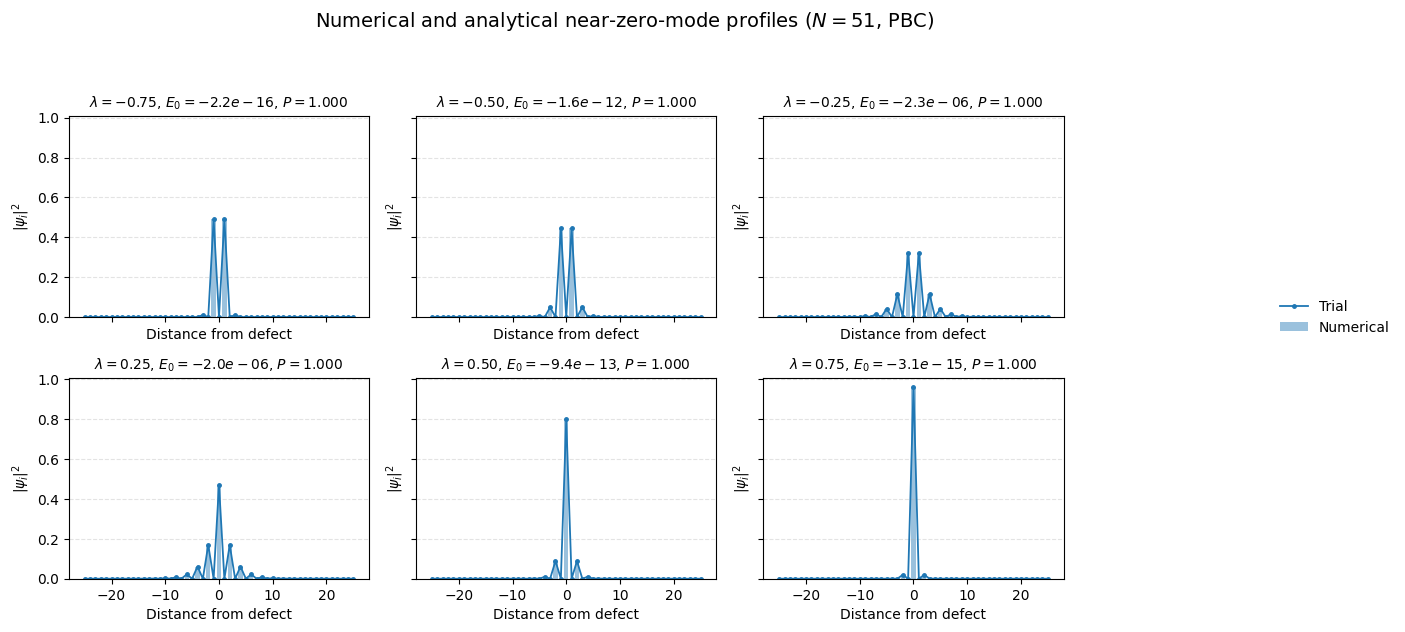

In [12]:
zero_mode_results = (
    plot_trial_vs_numerical_zero_mode(
        N=N,
        beta=BETA,
        lambda_values=[
            -0.75,
            -0.50,
            -0.25,
            0.25,
            0.50,
            0.75,
        ],
        periodic=PERIODIC,
        centered=True,
        center_site=0,
        savepath="near_zero_mode_profiles.pdf",
    )
)

In [13]:
decomposition = two_site_defect_decomposition(
    N=N,
    lam=LAMBDA_TEST,
    beta=BETA,
    pair=(0, 1),
    periodic=PERIODIC,
)

print("C_defect =")
print(decomposition["C_defect"])

print("\nC_bulk =")
print(decomposition["C_bulk"])

print("\nC_zero =")
print(decomposition["C_zero"])

print("\nResidual =")
print(decomposition["residual"])

print(
    "\nReconstruction error:",
    decomposition["reconstruction_error"],
)

C_defect =
[[ 0.5        -0.15600283]
 [-0.15600283  0.5       ]]

C_bulk =
[[ 0.5        -0.08454196]
 [-0.08454196  0.5       ]]

C_zero =
[[ 4.00000000e-01 -4.72094155e-13]
 [-4.72094155e-13  5.57182228e-25]]

Residual =
[[-4.00000000e-01 -7.14608672e-02]
 [-7.14608672e-02  3.38618023e-14]]

Reconstruction error: 0.0


In [14]:
C_reconstructed = (
    decomposition["C_bulk"]
    + decomposition["C_zero"]
    + decomposition["residual"]
)

print(
    "Exact reconstruction:",
    np.allclose(
        decomposition["C_defect"],
        C_reconstructed,
    ),
)

Exact reconstruction: True


In [15]:
print(
    "Residual norm:",
    np.linalg.norm(
        decomposition["residual"]
    ),
)

Residual norm: 0.4125691591577228


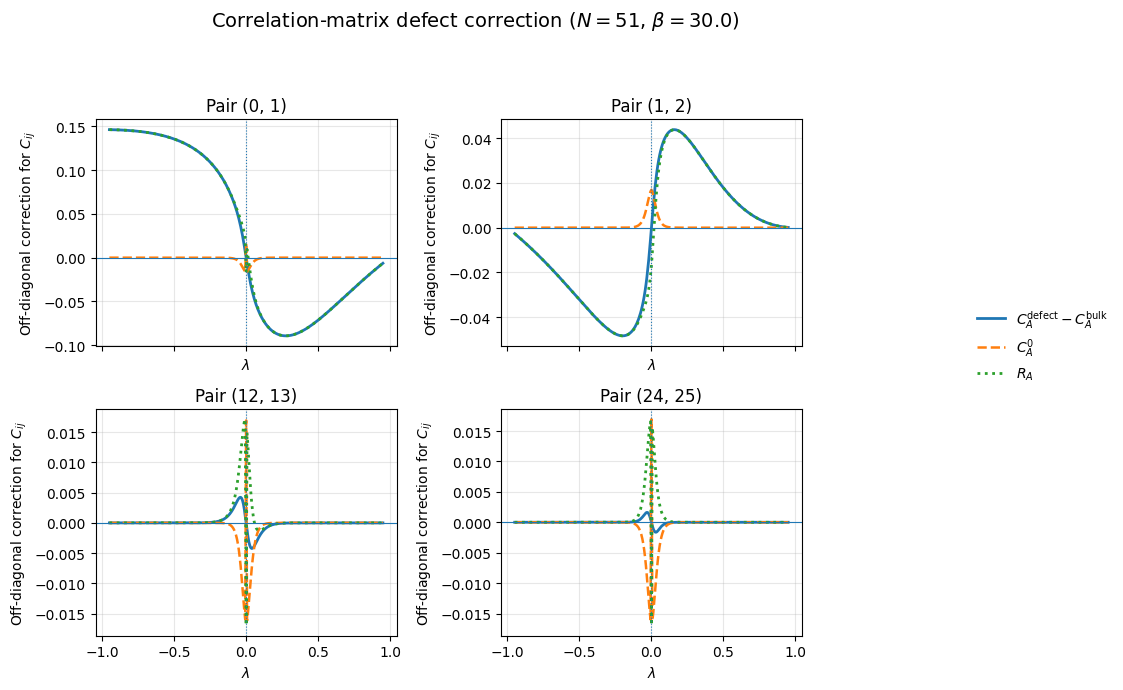

In [16]:
correlation_decomposition_data = (
    plot_correlation_decomposition_vs_lambda(
        N=N,
        beta=BETA,
        lambda_values=LAMBDA_VALUES,
        selected_pairs=SELECTED_PAIRS,
        periodic=PERIODIC,
        matrix_element="offdiagonal",
        savepath="correlation_decomposition_offdiagonal.pdf",
    )
)

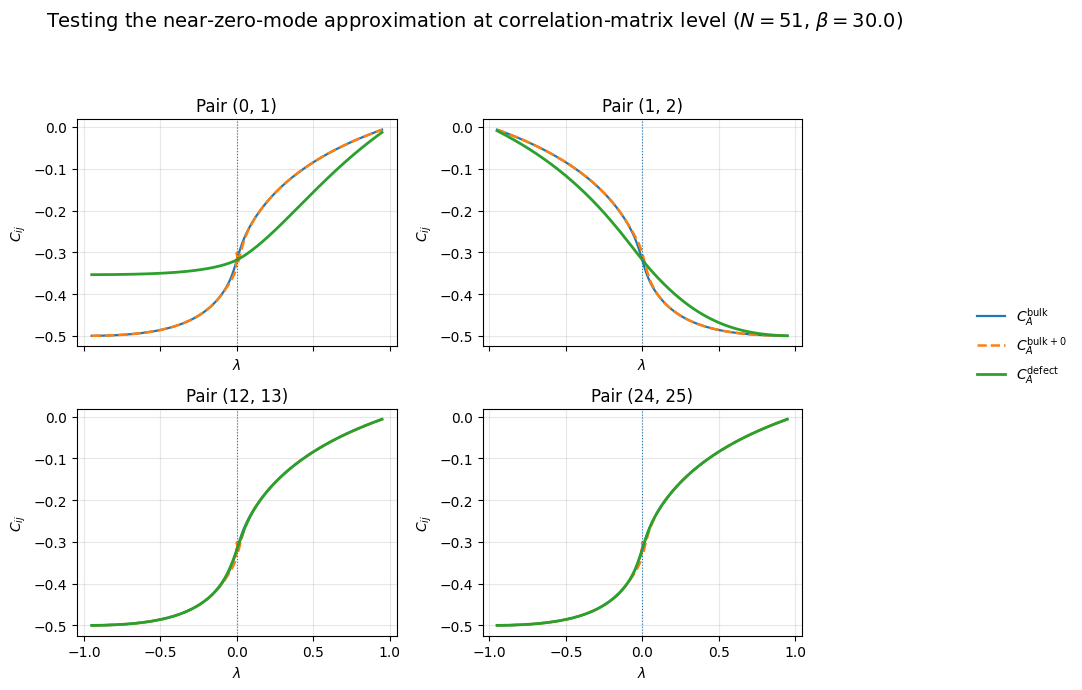

In [17]:
correlation_approximation_data = (
    plot_correlation_approximation_vs_lambda(
        N=N,
        beta=BETA,
        lambda_values=LAMBDA_VALUES,
        selected_pairs=SELECTED_PAIRS,
        periodic=PERIODIC,
        matrix_element="offdiagonal",
        savepath="correlation_bulk_zero_defect.pdf",
    )
)

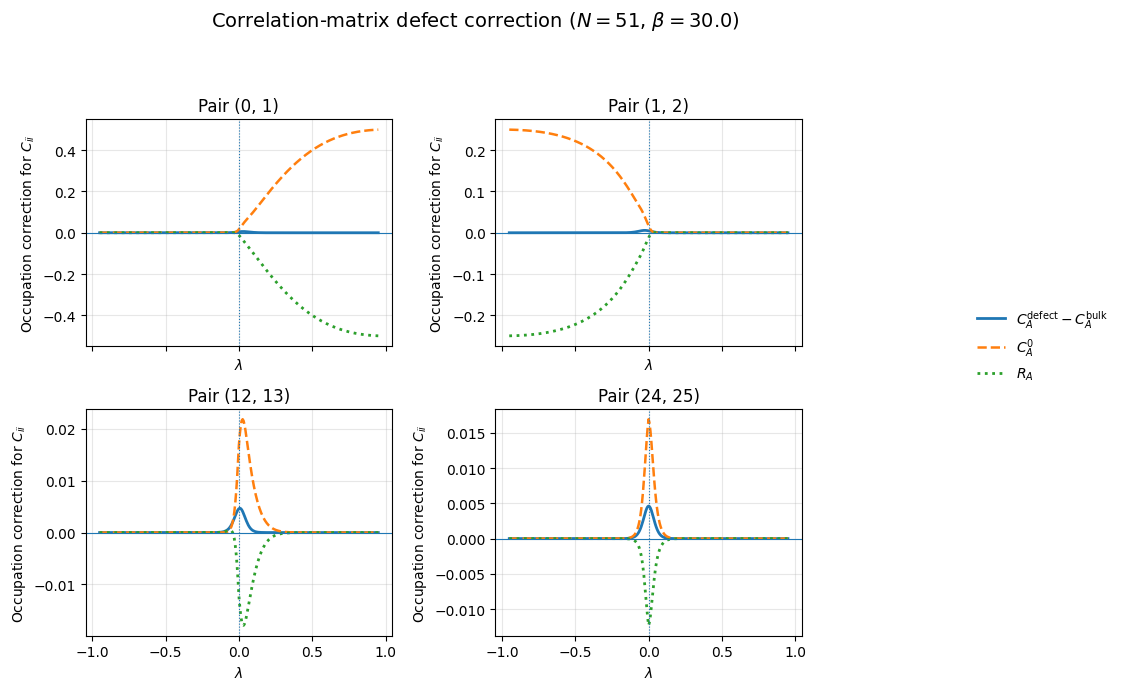

In [18]:
correlation_diagonal_data = (
    plot_correlation_decomposition_vs_lambda(
        N=N,
        beta=BETA,
        lambda_values=LAMBDA_VALUES,
        selected_pairs=SELECTED_PAIRS,
        periodic=PERIODIC,
        matrix_element="site_i",
        savepath="correlation_decomposition_diagonal.pdf",
    )
)

In [19]:
concurrence_result = compare_pair_concurrences(
    N=N,
    lam=LAMBDA_TEST,
    beta=BETA,
    pair=(0, 1),
    periodic=PERIODIC,
)

print(
    "Bulk concurrence:",
    concurrence_result["concurrence_bulk"],
)

print(
    "Bulk + zero concurrence:",
    concurrence_result["concurrence_approx"],
)

print(
    "Full defect concurrence:",
    concurrence_result["concurrence_defect"],
)

print(
    "Approximation error:",
    concurrence_result["concurrence_defect"]
    - concurrence_result["concurrence_approx"],
)

Bulk concurrence: 0.0
Bulk + zero concurrence: 0.0
Full defect concurrence: 0.0
Approximation error: 0.0


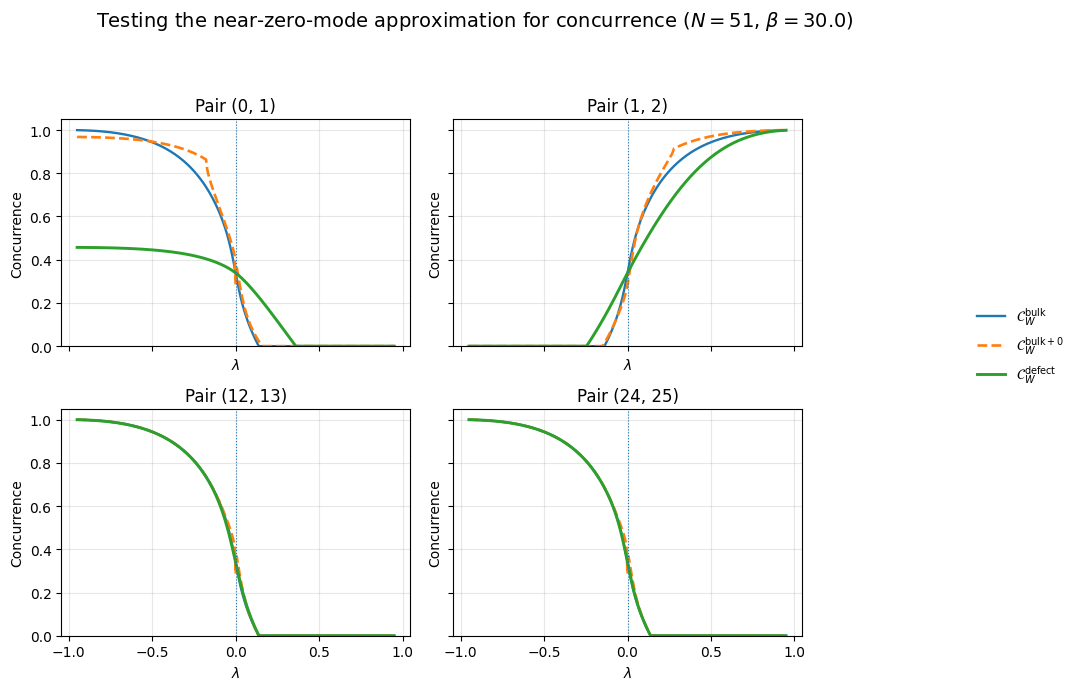

In [20]:
concurrence_data = (
    plot_concurrence_comparison_vs_lambda(
        N=N,
        beta=BETA,
        lambda_values=LAMBDA_VALUES,
        selected_pairs=SELECTED_PAIRS,
        periodic=PERIODIC,
        savepath="concurrence_bulk_zero_defect.pdf",
    )
)